In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
m = pd.read_csv("simulation_results/metrics_20250913_124425.csv")

## Average Latency

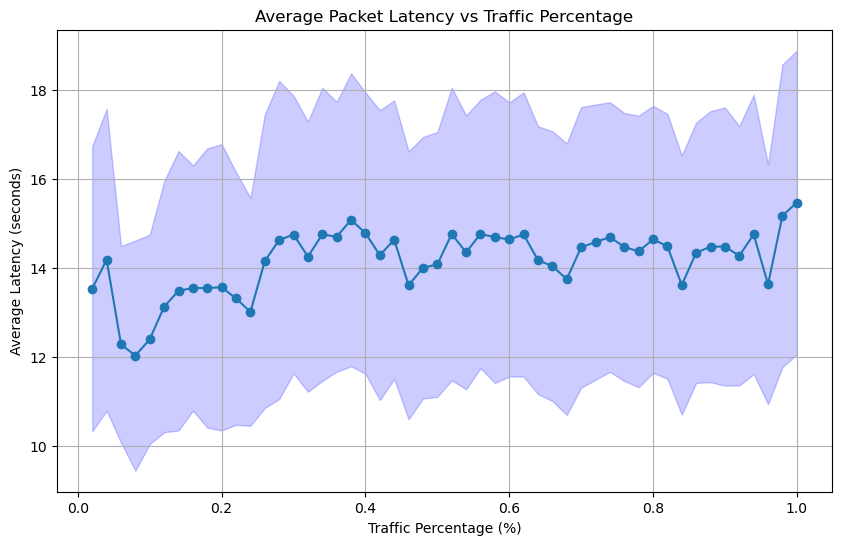

In [19]:
# Filter for packet_arrived
arrived = m[m['type'] == 'packet_arrived'].copy()
# Convert to datetime if not already
arrived['creation_time'] = pd.to_datetime(arrived['creation_time'])
arrived['deliver_time'] = pd.to_datetime(arrived['deliver_time'])
# Calculate latency in seconds
arrived['latency_sec'] = (arrived['deliver_time'] - arrived['creation_time']).dt.total_seconds()
# Show the result
latency = arrived.groupby('traffic').agg({'latency_sec': ['mean', 'std', 'min', 'max']})

plt.figure(figsize=(10, 6))
plt.plot(latency.index, latency['latency_sec']['mean'], marker='o')
plt.fill_between(latency.index,
                 latency['latency_sec']['mean'] - latency['latency_sec']['std'],
                 latency['latency_sec']['mean'] + latency['latency_sec']['std'],
                 color='b', alpha=0.2)
plt.title('Average Packet Latency vs Traffic Percentage')
plt.xlabel('Traffic Percentage (%)')
plt.ylabel('Average Latency (seconds)')
plt.grid(True)
plt.show()